In [1]:
from google.colab import drive
drive.mount("/content/drive")

import glob
import pandas as pd

base = "/content/drive/MyDrive/ifood_marketing_analytics"
files = glob.glob(base + "/**/*.csv", recursive=True)
files

Mounted at /content/drive


['/content/drive/MyDrive/ifood_marketing_analytics/data/ifood_df.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/target_list_top200.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/ifood_scored_all_customers.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/ifood_with_segments.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/segment_profile.csv']

In [2]:
path = base + "/outputs/ifood_with_segments.csv"
df = pd.read_csv(path)

print("Loaded:", path)
print("Shape:", df.shape)
df.head()

Loaded: /content/drive/MyDrive/ifood_marketing_analytics/outputs/ifood_with_segments.csv
Shape: (2205, 45)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,CustomerID,TotalKids,TotalPurchases,DealShare,Segment,SegmentName
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,1529,1441,0,1,0,25,0.120000,2,Quiet Value Regulars
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,21,15,0,2,2,6,0.333333,1,Deal Driven Browsers
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,734,692,0,3,0,21,0.047619,2,Quiet Value Regulars
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,48,43,0,4,1,8,0.250000,1,Deal Driven Browsers
4,58293.0,1,0,94,173,43,118,46,27,15,...,1,407,392,0,5,1,19,0.263158,2,Quiet Value Regulars


In [3]:
df["Response"].mean()

np.float64(0.1510204081632653)

In [4]:
cols = ["Income","Recency","MntTotal","NumWebVisitsMonth"]
df.groupby("Response")[cols].mean().T

Response,0,1
Income,50094.496261,60209.675676
Recency,51.454060,35.264264
MntTotal,498.433761,924.408408
NumWebVisitsMonth,5.342415,5.306306


In [5]:
import numpy as np

df["CustomerID"] = np.arange(1, len(df) + 1)

df["TotalPurchases"] = (
    df["NumDealsPurchases"]
    + df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

df["DealShare"] = np.where(df["TotalPurchases"] > 0,
                           df["NumDealsPurchases"] / df["TotalPurchases"],
                           0)

df[["CustomerID","TotalPurchases","DealShare"]].head()

,CustomerID,TotalPurchases,DealShare
0,1,25,0.120000
1,2,6,0.333333
2,3,21,0.047619
3,4,8,0.250000
4,5,19,0.263158


In [6]:
print(df.shape)
df[["CustomerID","TotalPurchases","DealShare"]].describe()

(2205, 45)


,CustomerID,TotalPurchases,DealShare
count,2205.000000,2205.000000,2205.000000
mean,1103.000000,14.887982,0.180428
std,636.672993,7.615277,0.110892
min,1.000000,0.000000,0.000000
25%,552.000000,8.000000,0.076923
50%,1103.000000,15.000000,0.166667
75%,1654.000000,21.000000,0.250000
max,2205.000000,43.000000,1.000000


In [7]:
response_rate = df["Response"].mean()
print("Response rate:", round(response_rate, 4))

Response rate: 0.151


In [8]:
cols = ["Income","Recency","MntTotal","TotalPurchases","DealShare","NumWebVisitsMonth","AcceptedCmpOverall"]
t = df.groupby("Response")[cols].mean().T
t.columns = ["NoResponse","Response"]
t

,NoResponse,Response
Income,50094.496261,60209.675676
Recency,51.454060,35.264264
MntTotal,498.433761,924.408408
TotalPurchases,14.388889,17.693694
DealShare,0.185284,0.153130
NumWebVisitsMonth,5.342415,5.306306
AcceptedCmpOverall,0.176816,0.987988


Spend by response

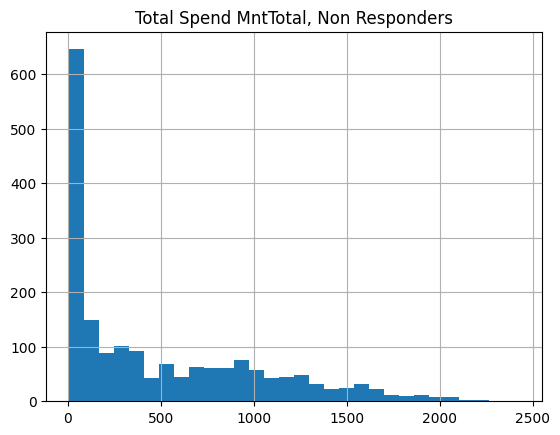

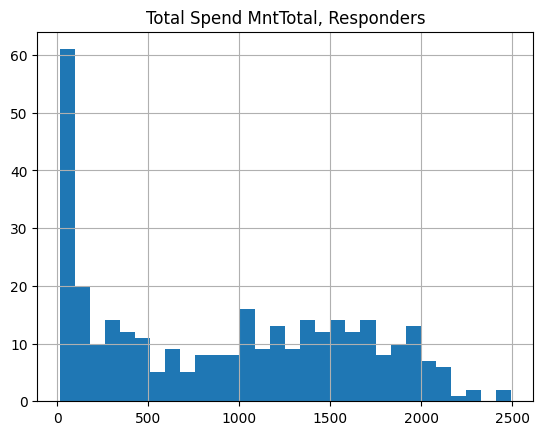

In [12]:
import matplotlib.pyplot as plt
import os

# Ensure the assets folder exists
assets_path = base + "/assets"
os.makedirs(assets_path, exist_ok=True)

plt.figure()
df[df["Response"]==0]["MntTotal"].hist(bins=30)
plt.title("Total Spend MntTotal, Non Responders")
plt.savefig(f"{assets_path}/total_spend_non_responders.png")
plt.show()

plt.figure()
df[df["Response"]==1]["MntTotal"].hist(bins=30)
plt.title("Total Spend MntTotal, Responders")
plt.savefig(f"{assets_path}/total_spend_responders.png")
plt.show()

Income quartile vs response

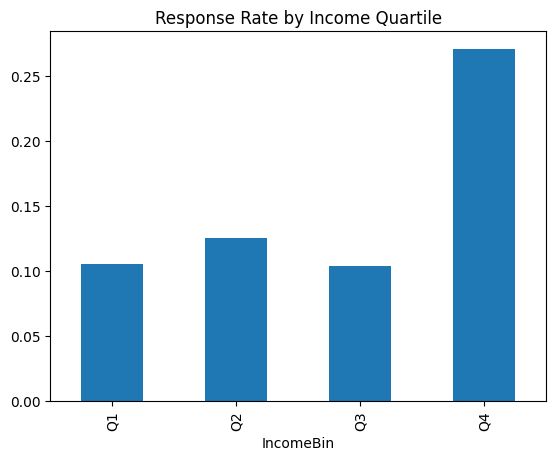

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df["IncomeBin"] = pd.qcut(df["Income"], 4, labels=["Q1","Q2","Q3","Q4"])
income_resp = df.groupby("IncomeBin", observed=False)["Response"].mean()

plt.figure()
income_resp.plot(kind="bar")
plt.title("Response Rate by Income Quartile")
plt.savefig(f"{assets_path}/response_rate_by_income_quartile.png")
plt.show()

Recency quartile vs response

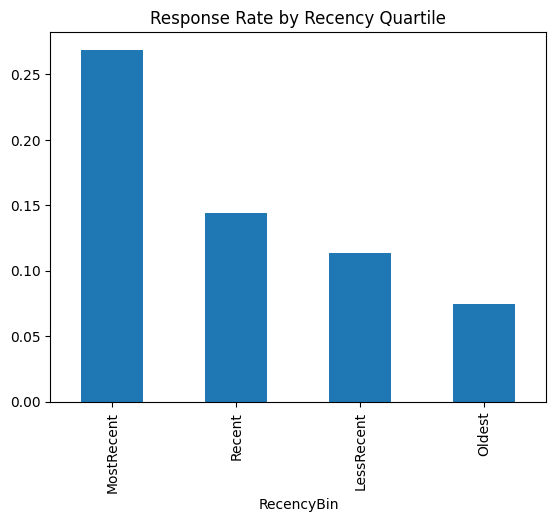

In [16]:
df["RecencyBin"] = pd.qcut(df["Recency"], 4, labels=["MostRecent","Recent","LessRecent","Oldest"])
recency_resp = df.groupby("RecencyBin", observed=False)["Response"].mean()

plt.figure()
recency_resp.plot(kind="bar")
plt.title("Response Rate by Recency Quartile")
plt.savefig(f"{assets_path}/response_rate_by_recency_quartile.png")
plt.show()

#Insights

1.	Customer value matters: responders have much higher total spend than non responders.
2.	Income is a targeting lever: top income quartile has the highest response rate, around 2x to 3x compared to other quartiles.
3.	Recency is the biggest lever: most recent buyers respond far more than the oldest group.
4.	This suggests a simple campaign plan: prioritize high income plus recent buyers first, then test reactivation for older buyers.
5.	Next step: segment customers and build a response model to generate a ranked targeting list.
